In [4]:
import pandas as pd


In [3]:
import re
def extract_numbers(route_name):
    # 使用正则表达式提取数字部分
    match = re.search(r'\d+', route_name)
    if match:
        return int(match.group())  # 返回数字部分并转换为整数
    return None  # 如果没有数字，返回 None

# 应用函数提取数字
Selected['ROUTE_NUM'] = Selected['ROUTE_NAMES'].apply(extract_numbers)

# 删除无效行（如果有）
Selected = Selected.dropna(subset=['ROUTE_NUM'])

# 绘制散点图
plt.figure(figsize=(10, 6))
plt.scatter(Selected['ROUTE_NUM'], Selected['PRICE'], color='blue', alpha=0.7)
plt.title('Scatter Plot of ROUTE_NUM vs PRICE')
plt.xlabel('ROUTE_NUM (Extracted Numbers)')
plt.ylabel('PRICE')
plt.grid(True)
plt.show()

NameError: name 'Selected' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro

plt.style.use('seaborn')

# 创建子图
fig, axes = plt.subplots(4, 4, figsize=(15, 10))  # 2 行 3 列的子图
fig.suptitle('Histograms and Normality Tests for Different Thresholds', fontsize=16)

# 迭代 threshold 从 8 到 13
thresholds = range(8, 15)
for i, threshold in enumerate(thresholds):
    # 筛选数据
    filtered_data = Selected[Selected['PRICE'] < threshold]['PRICE']
    filtered_data = filtered_data.sample(n=500, random_state=42)
    # 绘制直方图
    ax = axes[i // 3, i % 3]  # 定位子图位置
    ax.hist(filtered_data, bins=10, color='blue', alpha=0.7, edgecolor='black')
    ax.set_title(f'Threshold = {threshold}')
    ax.set_xlabel('PRICE')
    ax.set_ylabel('Frequency')
    
    # Shapiro-Wilk 正态性检验
    stat, p_value = shapiro(filtered_data)
    if p_value > 0.05:
        print(f"For threshold = {threshold}: Data looks normally distributed (fail to reject H0) with p-value:{p_value}")
    else:
        print(f"For threshold = {threshold}: Data does not look normally distributed (reject H0) with p-value:{p_value}")

# 调整布局
plt.tight_layout(rect=[0, 0, 1, 0.96])  # 调整子图间距
plt.show()

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = '../Data/Bus/Converted_Fare.xlsx'
df_converted_fare = pd.read_excel(file_path, engine='openpyxl')
df_converted_fare.head()

,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,LAST_UPDATE_DATE,ROUTE_NAMES,COMPANY_CODE,SERVICE_MODE,SPECIAL_TYPE,...,ON_SEQ_STOP_ID,STOP_SEQ_y,STOP_NAMES_y,OFF_SEQ_STOP_ID,ON_SEQ_STOP_X,ON_SEQ_STOP_Y,OFF_SEQ_STOP_X,OFF_SEQ_STOP_Y,ON_DISTRICT,OFF_DISTRICT
0,1001,1,1,2,6.7,2025-01-02,1,KMB,R,0,...,4001,2,天虹小学,4002,837872,822918,837621,822886,黃大仙,黃大仙
1,1001,1,1,3,6.7,2025-01-02,1,KMB,R,0,...,4001,3,马仔坑游乐场,4003,837872,822918,837391,822793,黃大仙,黃大仙
2,1001,1,1,4,6.7,2025-01-02,1,KMB,R,0,...,4001,4,摩士公园,4004,837872,822918,837557,822294,黃大仙,黃大仙
3,1001,1,1,5,6.7,2025-01-02,1,KMB,R,0,...,4001,5,摩士公园体育馆,4005,837872,822918,837610,822082,黃大仙,黃大仙
4,1001,1,1,6,6.7,2025-01-02,1,KMB,R,0,...,4001,6,伟东楼,4006,837872,822918,837768,821807,黃大仙,黃大仙


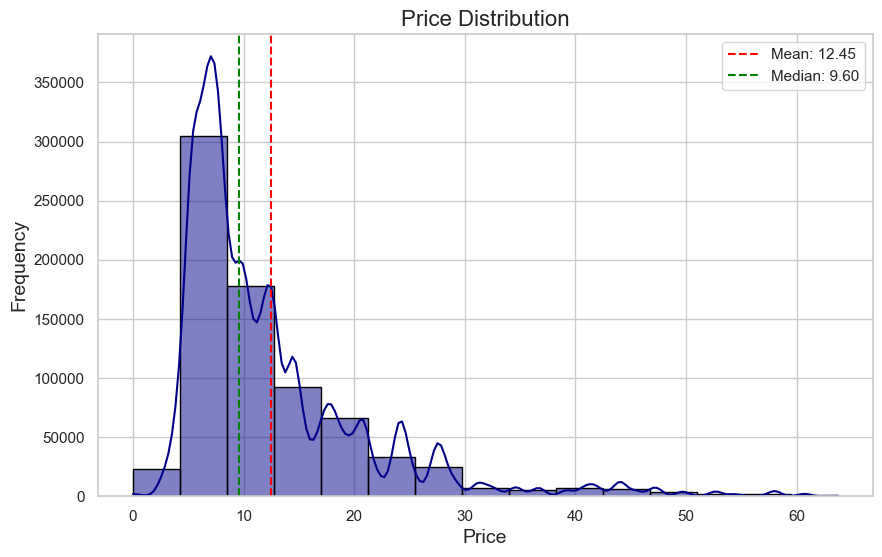

In [64]:
mean_price = df['PRICE'].mean()
median_price = df['PRICE'].median()

sns.set(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(df['PRICE'], bins=15, kde=True, color='darkblue', edgecolor='black')

plt.title('Price Distribution', fontsize=16)
plt.xlabel('Price', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.axvline(mean_price, color='red', linestyle='--', label=f'Mean: {mean_price:.2f}')
plt.axvline(median_price, color='green', linestyle='--', label=f'Median: {median_price:.2f}')


plt.legend()


plt.show()

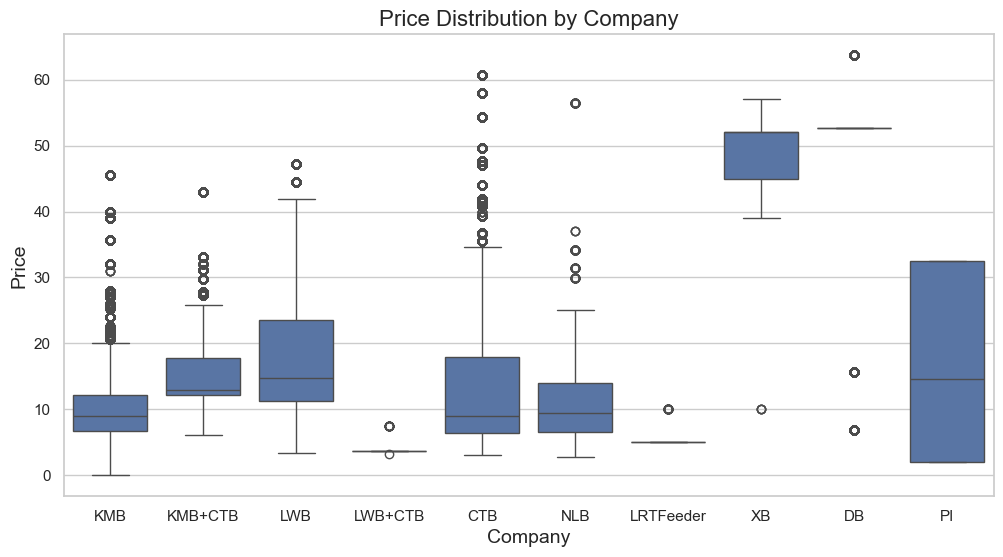

In [42]:
# 不同公司票价箱线图
sns.set(style='whitegrid')


plt.figure(figsize=(12, 6))
sns.boxplot(x='COMPANY_CODE', y='PRICE', data=df_converted_fare)

plt.title('Price Distribution by Company', fontsize=16)
plt.xlabel('Company', fontsize=14)
plt.ylabel('Price', fontsize=14)

plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\W'
<>:3: SyntaxWarning: invalid escape sequence '\W'
C:\Users\Tiger2022\AppData\Local\Temp\ipykernel_1972\1548917098.py:3: SyntaxWarning: invalid escape sequence '\W'
  font_path = 'C:\Windows\Fonts\mingliu.ttc'
C:\Users\Tiger2022\AppData\Local\Temp\ipykernel_1972\1548917098.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x='ON_DISTRICT', y='PRICE', data=average_price, palette='muted')


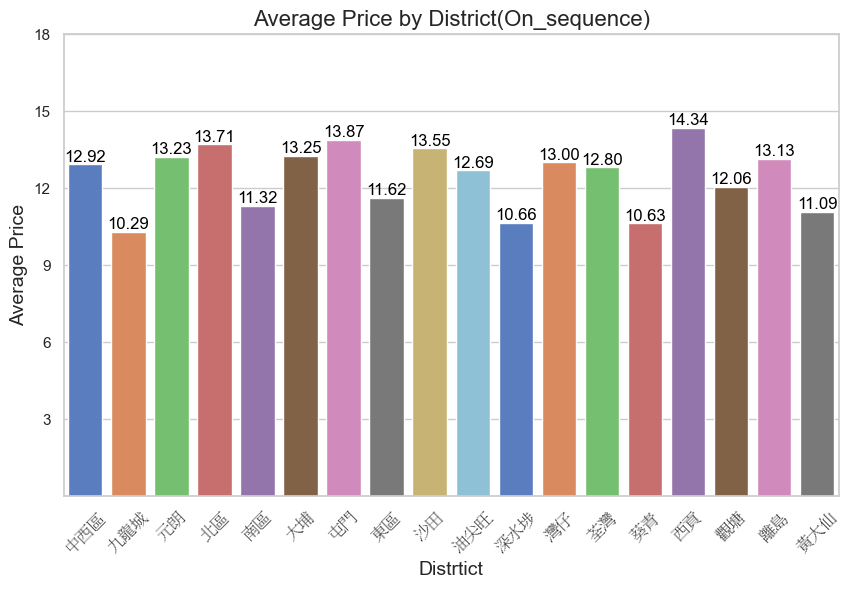

In [60]:
from matplotlib import font_manager

font_path = 'C:\Windows\Fonts\mingliu.ttc'
font_prop = font_manager.FontProperties(fname=font_path)

average_price = df.groupby('ON_DISTRICT')['PRICE'].mean().reset_index()

sns.set(style='whitegrid')

plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(x='ON_DISTRICT', y='PRICE', data=average_price, palette='muted')

plt.title('Average Price by District(On_sequence)', fontsize=16)
plt.xlabel('Distrtict', fontsize=14)
plt.ylabel('Average Price', fontsize=14)

plt.xticks(rotation=45, fontproperties=font_prop)
plt.yticks(ticks=[3, 6, 9, 12, 15, 18])

for p in bar_plot.patches:
    bar_plot.annotate(f'{p.get_height():.2f}', 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha='center', va='bottom', 
                      fontsize=12, color='black')
plt.show()

In [66]:
df_converted_fare['SERVICE_MODE'].unique()

array(['R', 'T', 'N', 'NT'], dtype=object)

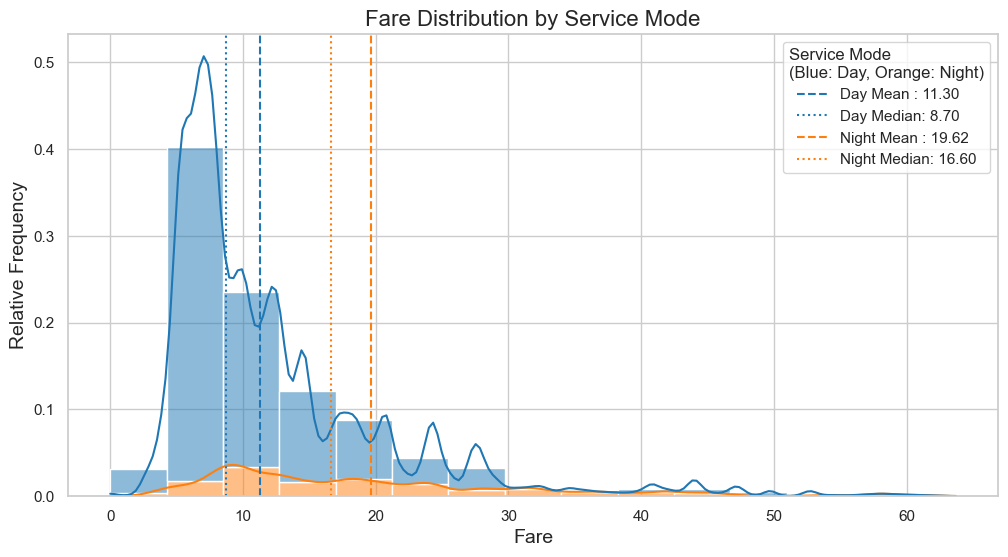

In [82]:
df_converted_fare['SERVICE_MODE'] = df_converted_fare['SERVICE_MODE'].replace({'N': 'Night', 'NT': 'Night', 'R': 'Day', 'T': 'Day'})

# 计算统计值
mode_stats = df_converted_fare.groupby('SERVICE_MODE')['PRICE'].agg(['mean', 'median', 'min', 'max']).reset_index()

# 设置绘图风格
sns.set(style='whitegrid')

# 创建直方图，纵坐标为相对频率
plt.figure(figsize=(12, 6))
palette = ['#1f77b4', '#ff7f0e']
sns.histplot(data=df_converted_fare, x='PRICE', bins=15, kde=True, hue='SERVICE_MODE', multiple='stack', alpha=0.5, palette=palette, stat='probability')

# 添加统计信息
for mode, color in zip(['Day', 'Night'], palette):
    mean_price = df_converted_fare[df_converted_fare['SERVICE_MODE'] == mode]['PRICE'].mean()
    median_price = df_converted_fare[df_converted_fare['SERVICE_MODE'] == mode]['PRICE'].median()
    
    plt.axvline(mean_price, linestyle='--', label=f'{mode} Mean : {mean_price:.2f}', color=color)
    plt.axvline(median_price, linestyle=':', label=f'{mode} Median: {median_price:.2f}', color=color)


# 添加标题和标签
plt.title('Fare Distribution by Service Mode', fontsize=16)
plt.xlabel('Fare', fontsize=14)
plt.ylabel('Relative Frequency', fontsize=14)

# 添加图例
plt.legend(title='Service Mode\n(Blue: Day, Orange: Night)')
plt.show()

In [132]:
file_path_2 = '../Data/Factors/DC_21C.CSV'
df_factor = pd.read_csv(file_path_2).head(22)
df_factor.head()

,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,按性別劃分的人口,按性別劃分的人口.1,性別比率（即男性數目與每千名女性相對的比率）,按年齡組別劃分的人口,按年齡組別劃分的人口.1,...,家庭住戶每月租金（港元）中位數,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.2,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.3,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.2
0,District Council district (class),District Council district,Name of District Council district (in English),Name of District Council district (in Chinese),Total population,Population by sex,Population by sex,Sex ratio (i.e. the number of males per 1 000 ...,Population by age group,Population by age group,...,Median monthly domestic household rent (HK$),Median monthly domestic household rent to inco...,Median floor area of accommodation of domestic...,Population aged 5 and over having internally m...,Population aged 5 and over having internally m...,Population aged 5 and over having internally m...,Population aged 5 and over having internally m...,Population aged 5 and over not having internal...,Population aged 5 and over not having internal...,Population aged 5 and over not having internal...
1,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,男性,女性,性別比率（即男性數目與每千名女性相對的比率）,15歲以下,15至24歲,...,家庭住戶每月租金（港元）中位數,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),香港島,九龍,新市鎮,新界其他地區／水上,曾在同區遷居,仍居舊址(23),居於香港以外地方
2,District Council district (class),District Council district,Name of District Council district (in English),Name of District Council district (in Chinese),Total population,Male,Female,Sex ratio (i.e. the number of males per 1 000 ...,< 15,15 - 24,...,Median monthly domestic household rent (HK$),Median monthly domestic household rent to inco...,Median floor area of accommodation of domestic...,Hong Kong Island,Kowloon,New towns,Other areas in the New Territories/ Marine,Moved home within same area of residence,Remained in same address(23),Place of residence outside Hong Kong
3,dc_class,dc,dc_eng,dc_chi,t_pop,pop_m,pop_f,sr,age_1,age_2,...,dm_r,dmr_ir,fa_m,pm_hk,pm_kln,pm_nt,pm_oth,pm_samearea,pm_same,pm_out
4,A,11,Central and Western,中西區,235953,98282,137671,714,24382,16779,...,15070,28,41,9932,5408,5799,1562,26614,153665,25390


In [134]:
df_factor.head(10)
len(df_factor)

22

In [136]:
df_factor = df_factor.drop(index=[0, 1, 2, 3]).reset_index(drop=True)
df_factor.head()

,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,按性別劃分的人口,按性別劃分的人口.1,性別比率（即男性數目與每千名女性相對的比率）,按年齡組別劃分的人口,按年齡組別劃分的人口.1,...,家庭住戶每月租金（港元）中位數,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.2,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.3,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.2
0,A,11,Central and Western,中西區,235953,98282,137671,714,24382,16779,...,15070,28,41,9932,5408,5799,1562,26614,153665,25390
1,B,12,Wan Chai,灣仔區,166695,67075,99620,673,16917,9907,...,16300,28.1,47,11587,4978,4826,1132,17262,104927,16873
2,C,13,Eastern,東區,529603,233542,296061,789,51517,36336,...,3520,19.3,44,15299,8426,10529,2079,46515,406489,26276
3,D,14,Southern,南區,263278,116239,147039,791,27255,18842,...,2850,15.7,41,10450,4560,4128,1508,20782,200203,14426
4,E,27,Yau Tsim Mong,油尖旺區,310647,138873,171774,808,36181,23224,...,7000,32,37,6925,14591,13189,2361,32320,197542,31863


In [140]:
df_factor['cost index'] = np.array([1.849309494,
3.075867121,
4.276393649,
5.492740232,
1.978903615,
5.082911945,
3.818203774,
2.114631448,
2.58581934,
2.169578909,
2.955856735,
1.776562612,
3.694651284,
2.218062621,
5.574087662,
2.01012663,
2.117823541,
3.17919441])
df_factor.head(18)


,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,按性別劃分的人口,按性別劃分的人口.1,性別比率（即男性數目與每千名女性相對的比率）,按年齡組別劃分的人口,按年齡組別劃分的人口.1,...,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.2,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.3,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.2,cost index
0,A,11,Central and Western,中西區,235953,98282,137671,714,24382,16779,...,28,41,9932,5408,5799,1562,26614,153665,25390,1.849309
1,B,12,Wan Chai,灣仔區,166695,67075,99620,673,16917,9907,...,28.1,47,11587,4978,4826,1132,17262,104927,16873,3.075867
2,C,13,Eastern,東區,529603,233542,296061,789,51517,36336,...,19.3,44,15299,8426,10529,2079,46515,406489,26276,4.276394
3,D,14,Southern,南區,263278,116239,147039,791,27255,18842,...,15.7,41,10450,4560,4128,1508,20782,200203,14426,5.492740
4,E,27,Yau Tsim Mong,油尖旺區,310647,138873,171774,808,36181,23224,...,32,37,6925,14591,13189,2361,32320,197542,31863,1.978904
5,F,23,Sham Shui Po,深水埗區,431090,197878,233212,848,49337,35476,...,19.6,34,10551,30888,27497,3168,37209,280486,27440,5.082912
6,G,24,Kowloon City,九龍城區,410634,179518,231116,777,50327,31113,...,21.8,40,6535,23590,18737,1582,39245,280084,27457,3.818204
7,H,25,Wong Tai Sin,黃大仙區,406802,187531,219271,855,36271,33463,...,13.2,38,3329,13981,8550,1113,16506,342007,12099,2.114631
8,J,26,Kwun Tong,觀塘區,673166,312303,360863,865,70063,60321,...,14.1,35,12725,33469,20901,2816,40809,523362,21920,2.585819
9,S,31,Kwai Tsing,葵青區,495798,232213,263585,881,49421,42474,...,12.6,37,4276,10233,15670,1617,20131,415788,14682,2.169579


C:\Users\Tiger2022\AppData\Local\Temp\ipykernel_1972\1761439078.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cost_index_correlation.index, y=cost_index_correlation.values, palette='viridis')


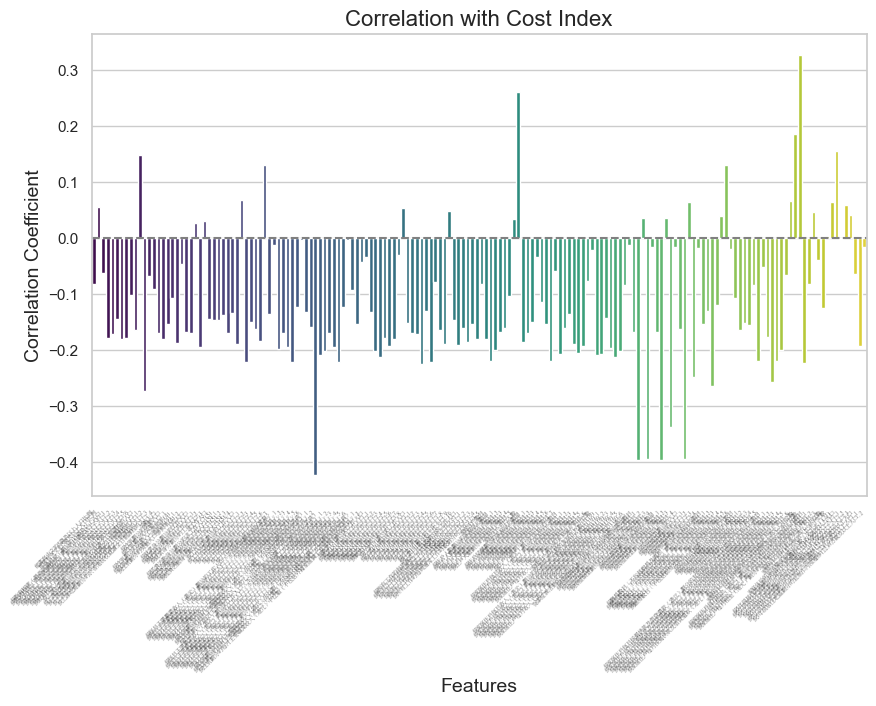

In [164]:
df_factor = df_factor.iloc[:, 4:]
df_factor = df_factor.apply(pd.to_numeric, errors='coerce')
correlation_matrix = df_factor.corr()

# 提取与 'cost index' 列的相关系数
cost_index_correlation = correlation_matrix['cost index'].drop('cost index')

# 可视化相关系数
plt.figure(figsize=(10, 6))
sns.barplot(x=cost_index_correlation.index, y=cost_index_correlation.values, palette='viridis')
plt.title('Correlation with Cost Index', fontsize=16)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Correlation Coefficient', fontsize=14)
plt.xticks(rotation=45, ha='right', fontproperties=font_prop, fontsize=4)
plt.axhline(0, color='gray', linestyle='--')
plt.show()

In [10]:
file_path_3 = '../Data/Bus/SelectedRoute.xlsx'
df_select = pd.read_excel(file_path_3, engine='openpyxl')
df_select.head()

,Unnamed: 0,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,ROUTE_NAMES,COMPANY_CODE,SERVICE_MODE,SPECIAL_TYPE,...,STOP_NAMES_y,OFF_SEQ_STOP_ID,ON_STOP_X,ON_STOP_Y,OFF_STOP_X,OFF_STOP_Y,ON_DISTRICT,OFF_DISTRICT,DISTANCE,COST_INDEX
0,271,1001,1,17,25,5.8,1,KMB,R,0,...,尖沙咀码头,4025,835531,819900,835463,817244,油尖旺,油尖旺,2724,0.024715
1,152,1001,1,8,14,6.7,1,KMB,R,0,...,拔萃男书院,4014,837429,821474,836023,820663,九龍城,九龍城,2217,0.023813
2,254,1001,1,15,25,6.7,1,KMB,R,0,...,尖沙咀码头,4025,835862,820632,835463,817244,油尖旺,油尖旺,3787,0.039692
3,5,1001,1,1,7,6.7,1,KMB,R,0,...,盈东楼,8090,837872,822918,837727,821666,黃大仙,黃大仙,1397,0.025438
4,525,1001,2,13,17,6.3,1,KMB,R,0,...,东宝庭道,4039,836322,820884,837258,821296,九龍城,九龍城,1348,0.013615


In [12]:
df_select = df_select[['ROUTE_ID', 'ROUTE_SEQ', 'ON_SEQ', 'OFF_SEQ', 'PRICE', 'COMPANY_CODE', 'SERVICE_MODE', 'SPECIAL_TYPE', 'ON_DISTRICT', 'OFF_DISTRICT', 'DISTANCE']]
df_select.head()

,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,COMPANY_CODE,SERVICE_MODE,SPECIAL_TYPE,ON_DISTRICT,OFF_DISTRICT,DISTANCE
0,1001,1,17,25,5.8,KMB,R,0,油尖旺,油尖旺,2724
1,1001,1,8,14,6.7,KMB,R,0,九龍城,九龍城,2217
2,1001,1,15,25,6.7,KMB,R,0,油尖旺,油尖旺,3787
3,1001,1,1,7,6.7,KMB,R,0,黃大仙,黃大仙,1397
4,1001,2,13,17,6.3,KMB,R,0,九龍城,九龍城,1348


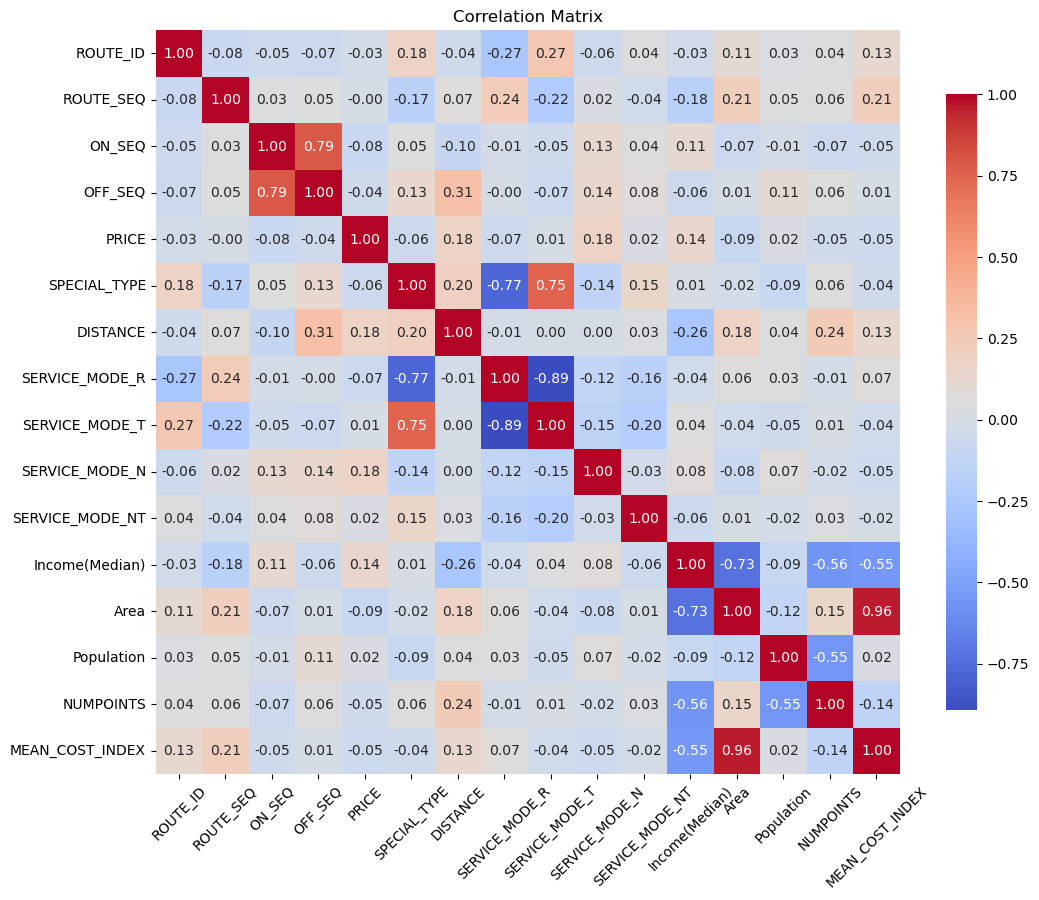

In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_select['SERVICE_MODE_R'] = np.where(df_select['SERVICE_MODE'] == 'R', 1, 0)
df_select['SERVICE_MODE_T'] = np.where(df_select['SERVICE_MODE'] == 'T', 1, 0)
df_select['SERVICE_MODE_N'] = np.where(df_select['SERVICE_MODE'] == 'N', 1, 0)
df_select['SERVICE_MODE_NT'] = np.where(df_select['SERVICE_MODE'] == 'NT', 1, 0)

file_path_4 = '../Data/Factors/Organized.xlsx'
df_organize = pd.read_excel(file_path_4, engine='openpyxl')
result = pd.merge(df_select, df_organize, left_on = 'ON_DISTRICT', right_on = '區議會分區', how = 'left')

file_path_5 = '../Data/Factors/Count.xlsx'
df_count = pd.read_excel(file_path_5, engine='openpyxl')
result = pd.merge(result, df_count, left_on = 'ON_DISTRICT', right_on = '地區', how = 'left')

result = result[['ROUTE_ID', 'ROUTE_SEQ', 'ON_SEQ', 'OFF_SEQ', 'PRICE', 'SPECIAL_TYPE', 'DISTANCE', 'SERVICE_MODE_R', 'SERVICE_MODE_T', 'SERVICE_MODE_N', 'SERVICE_MODE_NT', 'Income(Median)', 'Area', 'Population', 'NUMPOINTS', 'MEAN_COST_INDEX']]



correlation_matrix = result.corr()


plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.xticks(rotation=45)


plt.show() 

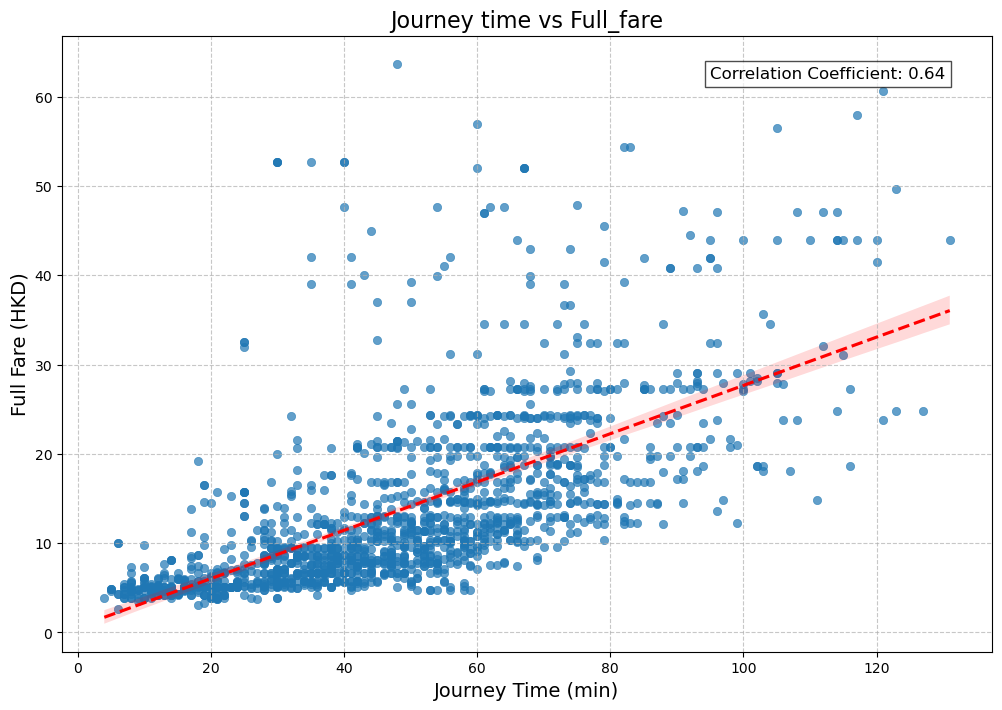

In [50]:
file_path = '../Data/Bus/ROUTE.xlsx'
df_route = pd.read_excel(file_path, engine='openpyxl')
correlation_coeff = df_route['JOURNEY_TIME'].corr(df_route['FULL_FARE'])

plt.figure(figsize=(12, 8))  
sns.scatterplot(data=df_route, x='JOURNEY_TIME', y='FULL_FARE', alpha=0.7, edgecolor=None)

# 添加回归线
sns.regplot(data=df_route, x='JOURNEY_TIME', y='FULL_FARE', scatter=False, color='red', line_kws={"linestyle": "--"})

# 设置标题和标签
plt.title('Journey time vs Full_fare', fontsize=16)
plt.xlabel('Journey Time (min)', fontsize=14)
plt.ylabel('Full Fare (HKD)', fontsize=14)

plt.text(0.95, 0.95, f'Correlation Coefficient: {correlation_coeff:.2f}', 
         horizontalalignment='right', verticalalignment='top', 
         transform=plt.gca().transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.7))


# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)

# 显示图形
plt.show()

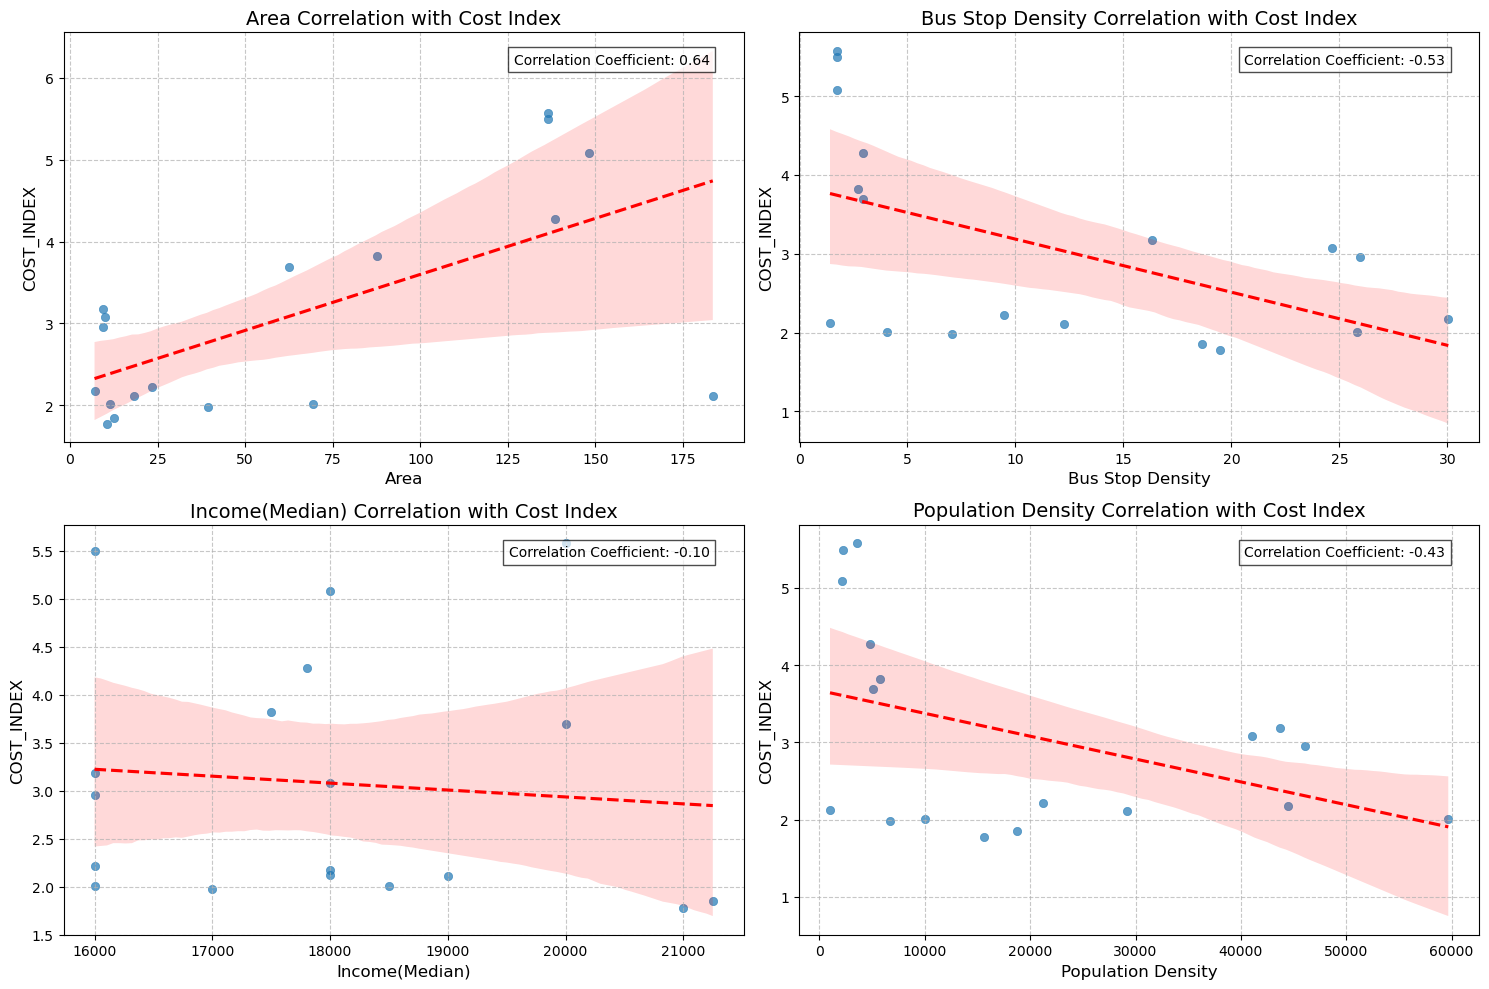

In [80]:
variables = ['Area', 'Bus Stop Density', 'Income(Median)', 'Population Density']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()  # 将 2D 数组展平，以便迭代

# 绘制每个变量与 COST_INDEX 的关系
for i, var in enumerate(variables):
    # 计算相关系数
    correlation_coeff = df_organize['MEAN_COST_INDEX'].corr(df_organize[var])
    
    # 绘制散点图
    sns.scatterplot(data=df_organize, x=var, y='MEAN_COST_INDEX', ax=axes[i], alpha=0.7, edgecolor=None)
    
    # 添加回归线
    sns.regplot(data=df_organize, x=var, y='MEAN_COST_INDEX', ax=axes[i], scatter=False, color='red', line_kws={"linestyle": "--"})
    
    # 设置标题和标签
    axes[i].set_title(f'{var} Correlation with Cost Index', fontsize=14)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel('COST_INDEX', fontsize=12)
    
    # 添加网格
    axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # 在右上角添加相关系数标签
    axes[i].text(0.95, 0.95, f'Correlation Coefficient: {correlation_coeff:.2f}', 
                 horizontalalignment='right', verticalalignment='top', 
                 transform=axes[i].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

# 调整布局
plt.tight_layout()
plt.show()